In [1]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [2]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json
import lightgbm as lgb

from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score,average_precision_score

In [3]:
# read bigquery data into pandas dataframe
import pandas as pd

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_31316/1097260367.py:4: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(


In [4]:
# Drop the unnecessary columns
df.drop(columns=['ip_addr', 'date_paid', 'status', 'items'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37372 entries, 0 to 37371
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      37372 non-null  Int64         
 1   customer_id   37372 non-null  Int64         
 2   date_created  37372 non-null  datetime64[us]
 3   total         37372 non-null  Int64         
dtypes: Int64(3), datetime64[us](1)
memory usage: 1.2 MB


### Create customer infomation table

- period: 2019-2020.12.31, 2021-2021.12.31, 2022-2024

In [6]:
def create_rfm_table(df, date_start, date_end, period=60, test=False):
    """
    Create the rfm table based of the given period of time.
    Churn: 1 for no transaction made in the observation period, vice versa

    :param date_start: The starting date of the dataset
    :param date_end: The ending date of the dataset
    :param period: Observation period, default 60 days
    :return: Return the rfm table created based on the period dataset
    """ 
    
    period_start = date_end - pd.DateOffset(days=period)

    table = df.copy()
    table.set_index('date_created', inplace=True) # setting Date as index
    table.sort_index(inplace=True)

    df_part1 = table.loc[date_start:period_start] # part of data that doesn't have last 60 days of transaction
    df_part1_obs = table.loc[period_start:date_end] # part of data that have only last 60 days of transaction

    # reseting the index
    df_part1.reset_index(inplace=True)
    df_part1_obs.reset_index(inplace=True)

    ## calculate the rfm
    rfm_df = df_part1.groupby('customer_id').agg(
        recency=('date_created', lambda x: (df_part1['date_created'].max() - x.max()).days),
        frequency=('date_created', 'count'),
        monetary=('total', 'sum')
    ).reset_index()

    # getting the number of customers in part1 and part2
    part1_customer = df_part1['customer_id'].sort_values().unique()
    part1_obs_customer = df_part1_obs['customer_id'].sort_values().unique()

    # finding whether the customer is churned or not
    rfm_df['churn'] = [0 if customer in part1_obs_customer else 1 for customer in part1_customer]

    # drop the customer_id as unnecessary
    if test == False:
        rfm_df.drop(['customer_id'], axis= 1, inplace= True)

    return rfm_df

In [7]:
first_order_dates = df['date_created'].min()
period_1 = pd.Timestamp('2020-12-31')
period_2 = pd.Timestamp('2021-12-31')
last_order_dates = df['date_created'].max()

rfm_part1 = create_rfm_table(df, first_order_dates, period_1)
rfm_part2 = create_rfm_table(df, period_1, period_2)
rfm_part3 = create_rfm_table(df, period_2, last_order_dates)

rfm_part4 = create_rfm_table(df, first_order_dates, period_2)
rfm_part5 = create_rfm_table(df, period_1, last_order_dates)

rfm_part6 = create_rfm_table(df, first_order_dates, first_order_dates + pd.DateOffset(days=365))
rfm_part7 = create_rfm_table(df, last_order_dates - pd.DateOffset(days=365), last_order_dates)
rfm_part8 = create_rfm_table(df, first_order_dates + pd.DateOffset(days=365), last_order_dates - pd.DateOffset(days=365))

test_set = create_rfm_table(df, first_order_dates, last_order_dates, test=True)

rfm_table = pd.concat([rfm_part1, rfm_part2,rfm_part3, rfm_part4, rfm_part5, rfm_part6, rfm_part7, rfm_part8], axis=0)

In [8]:
rfm_table = rfm_table[rfm_table['recency'] < 40]
test_set = test_set[test_set['recency'] < 40]

In [9]:
rfm_table.churn.value_counts()

churn
0    1056
1     617
Name: count, dtype: int64

In [10]:
test_set.churn.value_counts()

churn
0    153
1     73
Name: count, dtype: int64

### Model

#### Data standardization & Data splitting

In [11]:
X = rfm_table.drop(['churn'], axis= 1)
y = rfm_table[['churn']].values.reshape(-1)

In [12]:
id_test = test_set['customer_id']
X_test = test_set.drop(['churn', 'customer_id'], axis= 1)
y_test = test_set[['churn']].values.reshape(-1)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and Transform The Data
X = scaler.fit_transform(X)
X_test = scaler.fit_transform(X_test)

In [14]:
from sklearn.model_selection import train_test_split

test_size = 0.2
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=42, shuffle=True)

#### LGB

In [15]:
import lightgbm as lgb

In [16]:
params = {
'objective': 'binary',
'boosting_type': 'gbdt',
'metric':'auc',
'num_leaves': 31,
'learning_rate': 0.05,
'scale_pos_weight': 0.5,
"verbose": 0,
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train)

clf = lgb.train(params,
                lgb_train, 
                valid_sets=[lgb_train, lgb_eval],
                num_boost_round=20,
                callbacks=[lgb.early_stopping(stopping_rounds=10),])

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[20]	training's auc: 0.914328	valid_1's auc: 0.883771


In [17]:
y_pred_proba = clf.predict(X_test, num_iteration=clf.best_iteration)

y_pred = (y_pred_proba > 0.5).astype("int")
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
    
print('The accuracy of prediction is:', accuracy)
print('The ROC AUC of prediction is:', roc_auc)
print('The F1 Score of prediction is:', f1)
print('The Precision of prediction is:', prec)
print('The Recall of prediction is:', rec)

The accuracy of prediction is: 0.7787610619469026
The ROC AUC of prediction is: 0.8137254901960783
The F1 Score of prediction is: 0.6835443037974683
The Precision of prediction is: 0.6352941176470588
The Recall of prediction is: 0.7397260273972602


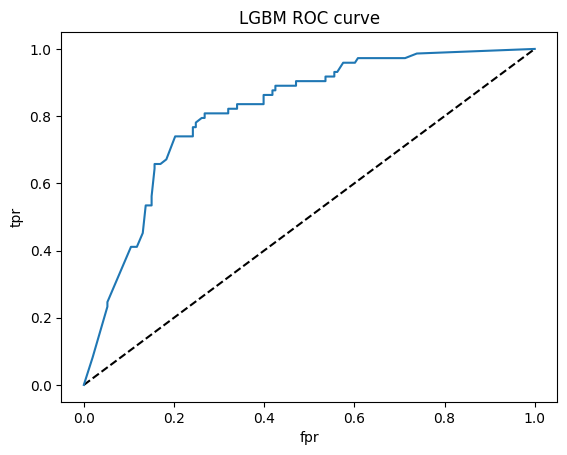

In [18]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='LGBM')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title(f'LGBM ROC curve')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

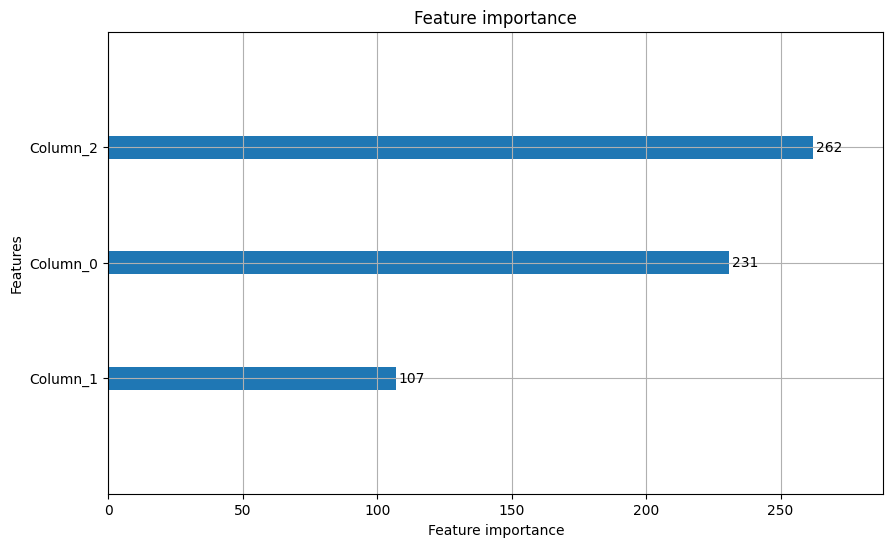

In [19]:
lgb.plot_importance(clf, figsize=(10, 6))

#### LGBMClassifier --- Used for finding valuable customers

In [77]:
params = {
'objective': 'binary',
'boosting_type': 'gbdt',
'metric':'auc',
'num_leaves': 30,
"max_depth": 7,
'learning_rate': 0.01,
'scale_pos_weight': 0.5,
"verbose": 1,
}

clf_binary = lgb.LGBMClassifier(**params).fit(X_train, y_train,eval_set=[(X_val,y_val),(X_train,y_train)])

[LightGBM] [Info] Number of positive: 483, number of negative: 855
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 432
[LightGBM] [Info] Number of data points in the train set: 1338, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.360987 -> initscore=-0.571085
[LightGBM] [Info] Start training from score -0.571085


In [78]:
predictions = clf_binary.predict_proba(X_test)


acc_bin  = accuracy_score(y_test, predictions[:,1] >= 0.5)
roc_auc_bin   = roc_auc_score(y_test, predictions[:,1])
f1_bin = f1_score(y_test, predictions[:,1] >= 0.5)
prec_bin = precision_score(y_test, predictions[:,1] >= 0.5)
rec_bin    = recall_score(y_test, predictions[:,1] >= 0.5)

print('The accuracy of prediction is:', acc_bin)
print('The ROC AUC of prediction is:', roc_auc_bin)
print('The F1 Score of prediction is:', f1_bin)
print('The Precision of prediction is:', prec_bin)
print('The Recall of prediction is:', rec_bin)

The accuracy of prediction is: 0.7787610619469026
The ROC AUC of prediction is: 0.8166353299310591
The F1 Score of prediction is: 0.6835443037974683
The Precision of prediction is: 0.6352941176470588
The Recall of prediction is: 0.7397260273972602


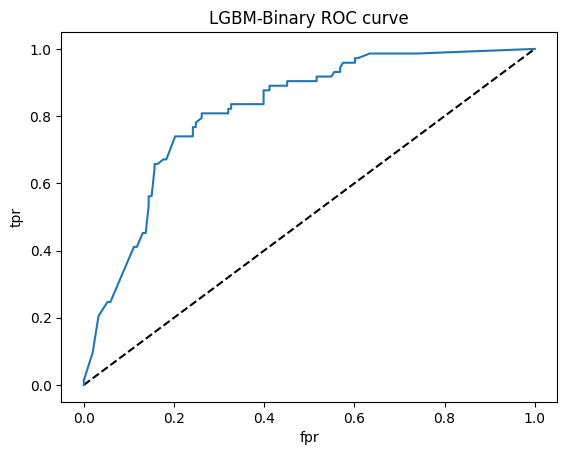

In [79]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, predictions[:,1])

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='LGBM-Binary')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title(f'LGBM-Binary ROC curve')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

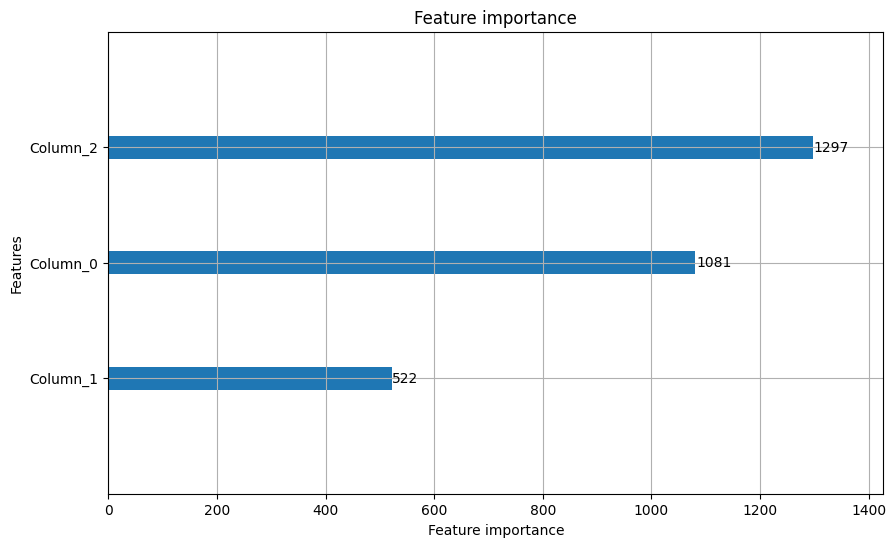

In [80]:
lgb.plot_importance(clf_binary, figsize=(10, 6))

In [81]:
print(classification_report(y_test, predictions[:,1] >= 0.5))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       153
           1       0.64      0.74      0.68        73

    accuracy                           0.78       226
   macro avg       0.75      0.77      0.76       226
weighted avg       0.79      0.78      0.78       226



##### Finding valuable customers

In [43]:
rfm_df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.nicole.rfm_new`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_31316/1240978552.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  rfm_df = pd.read_gbq(


过去消费 * churn rate = expected value lost -> 做排序top多少 找出最有价值的客户（）


筛选条件：
- 60天内无回购 （churn = 1）
- prediction 概率 >= 0.5
- 消费过3次以上 （frequency >= 3）

In [93]:
test_set.reset_index(drop=True, inplace=True)
predictions_df = pd.DataFrame({'prediction': predictions[:,1]})
merged_df = pd.concat([test_set, predictions_df], axis=1)

# calculate the expected value lost
merged_df["expected_value_lost"] = merged_df.monetary * merged_df.prediction

# sort the lost customers by the value lost
sorted_df = merged_df[(merged_df['churn'] == 1) & (merged_df['prediction'] >= 0.5) & (merged_df['frequency'] >= 2)].sort_values(by='expected_value_lost', ascending=False)

# merge the RFM segment value into the table
sorted_df = pd.merge(sorted_df, rfm_df[['customer_id', 'Segment']], on='customer_id', how='left')


In [94]:
sorted_df

,customer_id,recency,frequency,monetary,churn,prediction,expected_value_lost,Segment
0,873,22,16,37570,1,0.657922,24718.112193,Champions
1,919,17,9,32080,1,0.657922,21106.122948,Champions
2,185,26,15,31780,1,0.624321,19840.923293,Champions
3,810,27,15,30230,1,0.624321,18873.22565,Champions
4,753,20,15,27420,1,0.657922,18040.20858,Champions
5,1524,16,16,26920,1,0.576695,15524.620843,Champions
6,1614,34,5,14340,1,0.742123,10642.041694,Champions
7,1649,33,7,15560,1,0.593241,9230.824811,Champions
8,1523,36,7,11730,1,0.736248,8636.190278,Champions
9,119,22,6,10900,1,0.741098,8077.964718,Champions


In [95]:
sum(sorted_df['expected_value_lost']) / 100

2459.476948166521

原始 churn rate：

- 73 / (153 + 73) ≈ 0.322

假设挽回了这31个人，修改后的 churn rate：
- (73 - 31) / (153 + 73 - 31) ≈ 0.215

变化百分比：
- (0.215 - 0.322) / 0.322 × 100% ≈ -33.23%

挽回金额：
- 2459.48

挽回金额百分比：
- 2459.48 / 18222.09 × 100% ≈ 13.50%


In [104]:
import pandas_gbq
pandas_gbq.to_gbq(sorted_df, 'jr-data-training.nicole.lost_customers', project_id="jr-data-training")

#### RANDOM FOREST

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20).fit(X_train, y_train)
#rf_over = RandomForestClassifier(n_estimators=20).fit(X_train_over, y_train_over)

In [29]:
predictions = pd.DataFrame()
predictions['true'] = y_train
predictions['preds'] = rf.predict(X_train)

In [30]:
predictions_test = pd.DataFrame()
predictions_test['true'] = y_test
predictions_test['preds'] = rf.predict(X_test)
predictions_test['proba'] = rf.predict_proba(X_test)[:, 1]
#predictions_test['preds_over'] = rf_over.predict(X_test)

In [31]:
from sklearn.metrics import classification_report, accuracy_score
train_acc = accuracy_score(predictions.true, predictions.preds)
test_acc = accuracy_score(predictions_test.true, predictions_test.preds)
#test_acc_over = accuracy_score(predictions_test.true, predictions_test.preds_over)

roc_auc_rf   = roc_auc_score(predictions_test.true, predictions_test.proba)

print('The ROC AUC of prediction is:', roc_auc_rf)
print(f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

The ROC AUC of prediction is: 0.7459038409884502
Train Acc: 0.9918, Test Acc: 0.6681


In [32]:
print(classification_report(predictions_test.true, predictions_test.preds))

              precision    recall  f1-score   support

           0       0.76      0.75      0.75       153
           1       0.49      0.49      0.49        73

    accuracy                           0.67       226
   macro avg       0.62      0.62      0.62       226
weighted avg       0.67      0.67      0.67       226



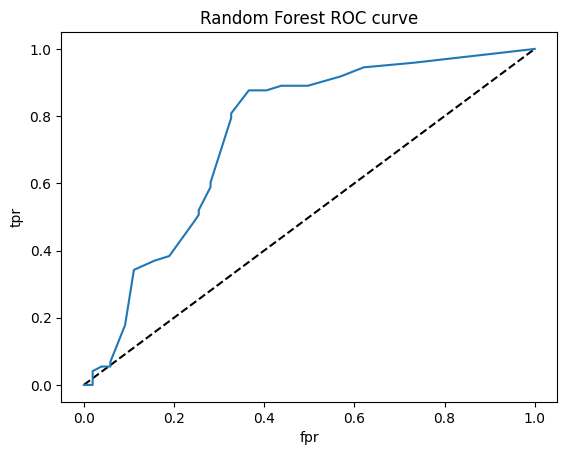

In [33]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(predictions_test.true, predictions_test.proba)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='Random Forest')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title(f'Random Forest ROC curve')
plt.show()

/Users/nicole/data-training/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


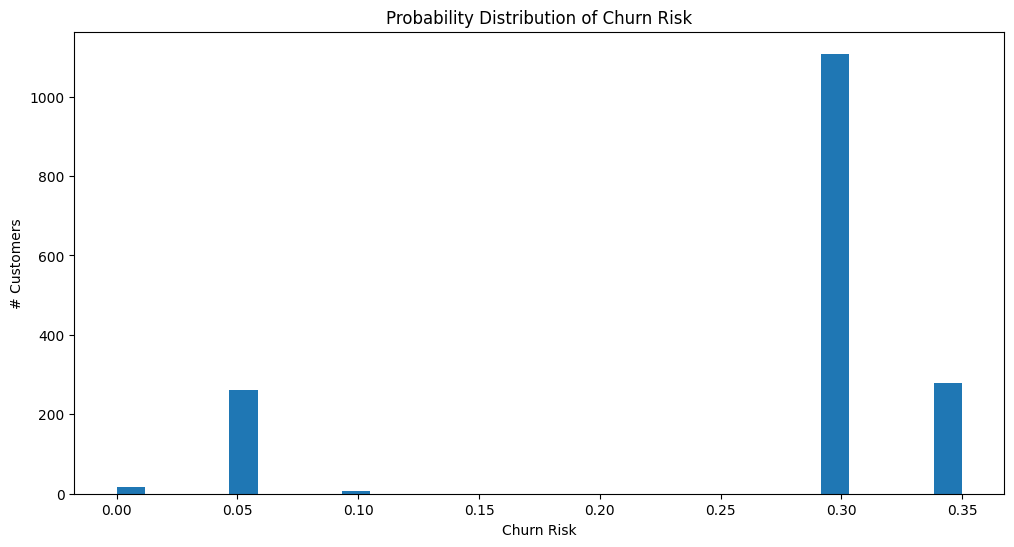

In [34]:
current_rfm = rfm_table.copy()
current_rfm.drop(columns=['churn'], inplace=True)
probs = rf.predict_proba(current_rfm)[:, 1]

plt.figure(figsize=(12, 6))
# matplotlib histogram
plt.hist(probs, bins = int(180/6))

plt.title('Probability Distribution of Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('# Customers')
plt.show()